  <h1 style="margin: 0;"><strong>Data Mining Project: Amazing International Airlines Inc.</strong></h1>
  <h2 style="margin: 0;"><strong>Part 2/2: Clustering</strong></h2>
</div>

<div style="text-align: left; margin-top: 15px;">
  <p style="margin: 0;"><strong>Group 51:</strong></p>
  <ul style="margin: 0; padding-left: 20px;">
    <li>André Ferreira | 20250398</li>
    <li>Fausto Gomes | 20221915</li>
    <li>Maria Francisca Gonçalves | 20221942</li>
    <li>Miguel Matos | 20221925</li>
  </ul>
</div>


# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [10]:
import os
import sys
import warnings

import sys
sys.path.append('../')

# Suppress warnings
warnings.filterwarnings('ignore')

### Basic Libraries
import numpy as np
import pandas as pd

### Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [11]:
#FUNÇOES

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import urllib
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import math

def set_plot_properties(ax, x_label, y_label, y_lim=[]):
    """
    Set properties of a plot axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        y_lim (list, optional): The limits for the y-axis. Defaults to [].

    Returns:
        None
    """
    ax.set_xlabel(x_label)  # Set the label for the x-axis
    ax.set_ylabel(y_label)  # Set the label for the y-axis
    if len(y_lim) != 0:
        ax.set_ylim(y_lim)  # Set the limits for the y-axis if provided


def plot_inertia_and_silhouette(data, k_min=2, k_max=15):
    """
    Plot the inertia (dispersion) and silhouette score for different numbers of clusters.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        k_min (int, optional): The minimum number of clusters to evaluate. Defaults to 2.
        k_max (int, optional): The maximum number of clusters to evaluate. Defaults to 15.

    Returns:
        None
    """
    dispersions = []
    scores = []

    k_clusters = range(k_min, k_max + 1)

    for k in k_clusters:
        kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
        dispersions.append(kmeans.inertia_)  # Calculate the dispersion (inertia) for each number of clusters
        kmeans.predict(data)
        scores.append(silhouette_score(data, kmeans.labels_, metric='euclidean'))  # Calculate the silhouette score

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(k_clusters, dispersions, marker='o')  # Plot the inertia (dispersion)
    set_plot_properties(ax1, 'Number of clusters', 'Dispersion (inertia)')
    ax2.plot(k_clusters, scores, marker='o')  # Plot the silhouette score
    set_plot_properties(ax2, 'Number of clusters', 'Silhouette score')

    plt.show()


def plot_dendrogram(data, linkage_method, cut_line=None):
    """
    Plot a dendrogram for hierarchical clustering.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        linkage_method (str): The linkage method used for clustering.
        cut_line (float, optional): The threshold value to cut the dendrogram. Defaults to None.

    Returns:
        None
    """
    # Fit the AgglomerativeClustering model
    model = AgglomerativeClustering(linkage=linkage_method, distance_threshold=0, n_clusters=None).fit(data)

    # Create the plot
    fig, ax = plt.subplots()
    plt.title('Hierarchical Clustering Dendrogram')

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Create the linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the dendrogram
    dendrogram(linkage_matrix, truncate_mode='level', p=50)

    # Add a cut line if provided
    if cut_line is not None:
        plt.axhline(y=cut_line, color='black', linestyle='-')

    # Display the plot
    plt.show()


def plot_umap_projections(people, cluster_columns, n_components=2, random_state=42):
    """
    Generates UMAP projections for multiple clustering methods and plots them in a grid.

    Parameters:
    people (DataFrame): The input data containing the features and cluster assignments.
    cluster_columns (list of str): The list of column names containing cluster assignments for each method.
    n_components (int): Number of dimensions for UMAP projection. Default is 2.
    random_state (int): Random state for UMAP. Default is 42.
    """
    # Check if at least one cluster column is provided
    if len(cluster_columns) < 1:
        raise ValueError("At least one cluster column must be provided.")

    # Determine the layout of subplots
    num_plots = len(cluster_columns)
    num_rows = math.ceil(math.sqrt(num_plots))
    num_cols = math.ceil(num_plots / num_rows)

    # Create the subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 12))
    axs = axs.flatten()  # Flatten the array of axes

    for i, cluster_column in enumerate(cluster_columns):
        # Check if the necessary columns are present in the dataframe
        if cluster_column not in people.columns:
            raise ValueError(f"Cluster column '{cluster_column}' not found in the data.")

        # Separate features and clusters
        features = people.drop(columns=[cluster_column])
        clusters = people[cluster_column]

        # Perform UMAP
        reducer = umap.UMAP(n_components=n_components, random_state=random_state)
        umap_embedding = reducer.fit_transform(features)

        # Plot the UMAP embedding
        scatter = axs[i].scatter(
            umap_embedding[:, 0], umap_embedding[:, 1],
            c=clusters, cmap='Spectral', s=5
        )
        axs[i].set_title(f'UMAP projection of {cluster_column}')
        axs[i].set_xlabel('UMAP 1')
        axs[i].set_ylabel('UMAP 2')

        # Add a color bar to each subplot
        cbar = plt.colorbar(scatter, ax=axs[i], boundaries=np.arange(clusters.nunique() + 1) - 0.5)
        cbar.set_ticks(np.arange(clusters.nunique()))

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout
    plt.tight_layout()
    plt.show()


def groupby_mean(data, variable, n_features=30):
    """
    Group the data by a variable and calculate the mean for each group.

    Args:
        data (pandas.DataFrame): The input data.
        variable (str): The variable used for grouping.
        n_features (int, optional): The number of features to include in the result. Defaults to 30.

    Returns:
        pandas.DataFrame: The transposed DataFrame containing the mean values for each group.
    """
    # Group the data by the specified variable and calculate the mean for each group
    grouped_data = data.groupby(variable).mean()

    # Select the first n_features + 1 columns (including the variable column) and transpose the DataFrame
    result = grouped_data.iloc[:, :n_features + 1].T

    # Return the transposed DataFrame
    return result

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [12]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

In [13]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16695 entries, 100011 to 999999
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16695 non-null  float64
 1   Customer Lifetime Value         16695 non-null  float64
 2   EnrollmentType                  16695 non-null  int64  
 3   rejoined_program                16695 non-null  int64  
 4   Days_in_prog                    16695 non-null  float64
 5   Cancelled_program               16695 non-null  int64  
 6   Enrollment_year                 16695 non-null  int64  
 7   Enrollment_month                16695 non-null  int64  
 8   Location_cluster                16695 non-null  int64  
 9   TotalFlights                    16695 non-null  float64
 10  TotalDistance                   16695 non-null  float64
 11  TotalPointsAccumulated          16695 non-null  float64
 12  TotalPointsRedeemed            

In [14]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [16]:
people1 = people.copy()

In [17]:
for column in people1.columns:
    if column.startswith('Total_Spend_Month_'):
        people1[column] = np.sqrt(people1[column])

In [18]:
people_st_scl = StandardScaler().fit_transform(people1)
people_mm_scl = MinMaxScaler().fit_transform(people1)
people_rb_scl = RobustScaler().fit_transform(people1)

## <h1 style="color: #333333; background-color: #b0cece; text-align: center; padding: 8px; font-family: 'Arial';">Modelling</h1>

In [ ]:
# Perspective 1: VALUE-BASED
value_features = [
    "Customer Lifetime Value",
    "TotalDistance",
    "TotalPointsAccumulated",
    "TotalPointsRedeemed",
    "Avg_spent_per_flight"
]

In [ ]:
# Perspective 2 — BEHAVIORAL
behavior_features = [
    "TotalFlights",
    "NumFlightsWithCompanions",
    "RecencyInMonths",
    "Flights_per_month",
    "PointsAccumulated_per_flight"]

In [ ]:
# Perspective 3 — DEMOGRAPHIC
demographic_features = ["Age", "Income"]

## <h2 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Perspective 1: VALUE-BASED SEGMENTATION</h2>

Prepare the data

In [ ]:
# Prepare data
customer_value = people[value_features].copy()

In [ ]:
# Apply sqrt transformation on spend/value columns
for column in customer_value.columns:
    if 'spend' in column.lower() or 'value' in column.lower() or 'distance' in column.lower():
        customer_value[column] = np.sqrt(customer_value[column])

In [ ]:
# Scaling
customer_value_st = StandardScaler().fit_transform(customer_value)
customer_value_rb = RobustScaler().fit_transform(customer_value)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Filtering: Examination 1</h3>

### K-Means

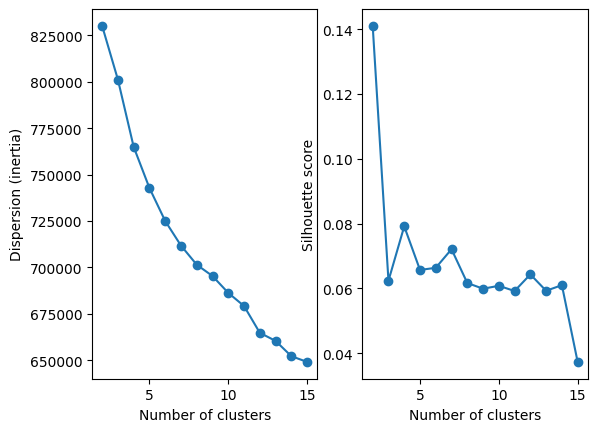

In [ ]:
print("VALUE PERSPECTIVE - Examination 1")
plot_inertia_and_silhouette(customer_value_rb)
plot_dendrogram(customer_value_rb, 'ward')

In [ ]:
n_clusters_value = 7
customer_value['value_exam1_ward'] = AgglomerativeClustering(
    linkage='ward', n_clusters=n_clusters_value
).fit_predict(customer_value_rb)

customer_value['value_exam1_kmeans'] = KMeans(
    n_clusters=n_clusters_value, random_state=42
).fit_predict(customer_value_rb)

In [ ]:
plot_umap_projections(customer_value, ['value_exam1_ward', 'value_exam1_kmeans'])

In [ ]:
print("VALUE - Ward Clustering Analysis")
display(groupby_mean(customer_value, 'value_exam1_ward'))

# %%
print("VALUE - K-Means Clustering Analysis")
display(groupby_mean(customer_value, 'value_exam1_kmeans'))